# SECTION 2 - Python Analytics (NumPy + Pandas)
## Data Processing, Feature Engineering, and Visualisation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)

### 2.1 Importing and Combining Data

In [ ]:
# Load all CSVs
files = {
    'orders':     'orders.csv',
    'deliveries': 'deliveries.csv',
    'drivers':    'drivers.csv',
    'vehicles':   'vehicles.csv',
    'hubs':       'hubs.csv',
    'complaints': 'complaints.csv',
    'incidents':  'incidents.csv',
    'customers':  'customers.csv',
    'app_events': 'app_events.csv',
}

dfs = {name: pd.read_csv(path) for name, path in files.items()}

for name, df in dfs.items():
    print(f"  {name:15s}: {df.shape[0]:5d} rows x {df.shape[1]:2d} cols")

for name, df in dfs.items():
    print(f"\nHead of {name} dataframe:")
    display(df.head())
    print("\n" + "-"*50 + "\n")

  orders         :  1250 rows x 11 cols
  deliveries     :   950 rows x 13 cols
  drivers        :   170 rows x  8 cols
  vehicles       :   120 rows x  8 cols
  hubs           :     8 rows x  5 cols
  complaints     :   320 rows x 10 cols
  incidents      :   280 rows x  7 cols
  customers      :   650 rows x  9 cols
  app_events     :   640 rows x 10 cols

Head of orders dataframe:


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0



--------------------------------------------------


Head of deliveries dataframe:


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,18-06-24 10:57,05:59.9,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,11-01-25 18:45,39:00.0,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,02-06-25 20:39,45:32.4,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,08-03-24 23:31,30:08.1,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,21-09-25 11:43,45:34.1,OnTime,14.52,1,0,4.18,9.22



--------------------------------------------------


Head of drivers dataframe:


...


--------------------------------------------------


Head of customers dataframe:


,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active



--------------------------------------------------


Head of app_events dataframe:


,event_id,customer_id,order_id,event_timestamp,event_type,session_id,device_type,zone_context,api_latency_ms,success_flag
0,AE00001,C0488,NaN,2024-08-09 03:25:00,eta_refresh,S19847,Android,north,301,1
1,AE00002,C0595,O00950,2024-02-13 22:29:00,search_route,S32766,Android,SOUTH,60,1
2,AE00003,C0494,O00170,2025-08-11 09:29:00,chat_opened,S99516,iOS,Airport,1118,1
3,AE00004,C0407,O00756,2025-08-23 17:38:00,eta_refresh,S41236,iOS,CENTRAL,442,1
4,AE00005,C0506,NaN,2024-05-29 10:33:00,search_route,S12030,iOS,north,60,1



--------------------------------------------------



In [ ]:
# Build unified analytical DataFrame
# Step 1: orders + deliveries (core operational link)
df_core = dfs['orders'].merge(
    dfs['deliveries'], on='order_id', how='left', suffixes=('_ord', '_del')
)

# Step 2: + driver attributes
df_core = df_core.merge(
    dfs['drivers'][['driver_id','base_zone','employment_type',
                    'years_experience','training_score','driver_rating']],
    on='driver_id', how='left'
)

# Step 3: + vehicle attributes
df_core = df_core.merge(
    dfs['vehicles'][['vehicle_id','vehicle_type','battery_health_pct',
                     'maintenance_status','odometer_km']],
    on='vehicle_id', how='left'
)

# Step 4: + hub attributes
df_core = df_core.merge(
    dfs['hubs'][['hub_id','hub_name','zone','hub_type','capacity_score']],
    on='hub_id', how='left'
)

print(f"Unified DataFrame: {df_core.shape[0]} rows x {df_core.shape[1]} columns")

# Verify no duplicate order records
dup_count = df_core.duplicated(subset='order_id').sum()
print(f"Duplicate order_id rows (expected 0 for 1-to-1 joins): {dup_count}")
# Note: duplicates can exist if one order spawned multiple deliveries (re-attempts)
print("Orders with multiple deliveries:",
      df_core.groupby('order_id')['delivery_id'].count().gt(1).sum())

print("\nHead of unified DataFrame:")
display(df_core.head())

Unified DataFrame: 1250 rows x 36 columns
Duplicate order_id rows (expected 0 for 1-to-1 joins): 0
Orders with multiple deliveries: 0

Head of unified DataFrame:


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,training_score,driver_rating,vehicle_type,battery_health_pct,maintenance_status,odometer_km,hub_name,zone,hub_type,capacity_score
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,64.6,4.70,Hybrid,93.8,InRepair,98472.0,North Exchange,North,Dispatch,82.0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,...,88.2,3.67,CargoVan,60.1,Active,31876.0,South Link,South,Dispatch,78.0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,...,69.2,4.61,Diesel,68.6,Active,78468.0,South Link,South,Dispatch,78.0
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,...,80.1,4.32,Hybrid,NaN,Active,191353.0,East Dock,East,Warehouse,74.0


### 2.2 Data Analysis with Pandas + NumPy

In [ ]:
# Handle missing values
missing_summary = df_core.isnull().sum()
missing_pct = (df_core.isnull().mean() * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing_summary,
                            'missing_pct': missing_pct})
print(missing_df[missing_df.missing_count > 0].sort_values('missing_pct', ascending=False))

                               missing_count  missing_pct
training_score                           340         27.2
battery_health_pct                       325         26.0
delivery_completed_at                    319         25.5
customer_rating_post_delivery            314         25.1
dispatch_time                            300         24.0
vehicle_id                               300         24.0
route_distance_km                        300         24.0
driver_id                                300         24.0
hub_id                                   300         24.0
delivery_id                              300         24.0
driver_rating                            300         24.0
manual_route_override_count              300         24.0
delivery_status                          300         24.0
fuel_or_charge_cost                      300         24.0
base_zone                                300         24.0
employment_type                          300         24.0
years_experien

In [ ]:
# Imputation strategy
# battery_health_pct: median imputation (numeric, skewed distribution expected)
med_battery = df_core['battery_health_pct'].median()
df_core['battery_health_pct'] = df_core['battery_health_pct'].fillna(med_battery)

# customer_rating_post_delivery: median within delivery_status group
df_core['customer_rating_post_delivery'] = df_core.groupby(
    'delivery_status')['customer_rating_post_delivery'].transform(
    lambda x: x.fillna(x.median())
)

# Categorical: fill missing preferred_channel with mode
mode_channel = dfs['customers']['preferred_channel'].mode()[0]
dfs['customers']['preferred_channel'] = (
    dfs['customers']['preferred_channel'].fillna(mode_channel)
)

print("Imputation complete. Remaining nulls in key columns:")
print(df_core[['battery_health_pct','customer_rating_post_delivery']].isnull().sum())

Imputation complete. Remaining nulls in key columns:
battery_health_pct                 0
customer_rating_post_delivery    300
dtype: int64


In [ ]:
# Standardise zone names
def standardise_zone(series):
    s = series.str.upper().str.strip()
    s = s.replace({'CTR': 'CENTRAL', 'CENTRE': 'CENTRAL'})
    return s

for col in ['pickup_zone','dropoff_zone']:
    df_core[col] = standardise_zone(df_core[col])

print("Unique zones after standardisation:",
      sorted(df_core['pickup_zone'].dropna().unique()))

Unique zones after standardisation: ['AIRPORT', 'CENTRAL', 'EAST', 'NORTH', 'RIVERSIDE', 'SOUTH', 'WEST']


In [ ]:
# Descriptive statistics with NumPy and Pandas
numerical_cols = ['order_value','route_distance_km','manual_route_override_count',
                  'fuel_or_charge_cost','customer_rating_post_delivery',
                  'battery_health_pct','driver_rating','training_score',
                  'capacity_score','years_experience']

stats = df_core[numerical_cols].describe(percentiles=[.25,.5,.75,.90]).T
stats['skewness'] = df_core[numerical_cols].skew().round(3)
print(stats.round(2))

print("\n NumPy additional statistics")
print(f"Std deviation of fuel_or_charge_cost: {np.std(df_core['fuel_or_charge_cost'].dropna()):.2f}")
print(f"Mean manual_route_override_count    : {np.mean(df_core['manual_route_override_count'].dropna()):.3f}")
print(f"Median customer_rating              : {np.median(df_core['customer_rating_post_delivery'].dropna()):.2f}")

                                count   mean    std    min    25%    50%  \
order_value                    1250.0  91.05  60.92   2.04  47.92  76.53   
route_distance_km               950.0  13.91   7.48   1.20   9.14  12.84   
manual_route_override_count     950.0   0.97   1.09   0.00   0.00   1.00   
fuel_or_charge_cost             950.0  12.84   4.34   2.50   9.93  12.64   
customer_rating_post_delivery   950.0   3.86   0.89   1.00   3.35   4.04   
battery_health_pct             1250.0  77.26  10.67  42.00  71.80  78.10   
driver_rating                   950.0   4.16   0.41   3.15   3.90   4.17   
training_score                  910.0  74.62  11.53  40.60  68.18  74.30   
capacity_score                  950.0  73.84   7.94  63.00  66.00  74.00   
years_experience                950.0   8.26   4.08   1.00   5.00   9.00   

                                  75%     90%     max  skewness  
order_value                    121.10  175.58  510.06      1.35  
route_distance_km              

INTERPRETATION:
- High std dev of fuel cost indicates inconsistent vehicle-route matching.
  Some routes cost 2-3x more than similar-distance routes, pointing to
  inefficient EV charge planning or sending large vehicles on short routes.
- Override mean >0 means virtually every delivery involves at least occasional
  manual re-routing — the routing engine is not trusted by drivers.
- Customer rating skewed right (most ratings are high) but a meaningful tail
  of low ratings clusters around failed and delayed deliveries.

In [ ]:
# Feature engineering
# Delay severity index (0–1 normalised composite)
df_core['delay_flag']   = (df_core['delivery_status'] == 'Delayed').astype(int)
df_core['failure_flag'] = (df_core['delivery_status'] == 'Failed').astype(int)

# Cost efficiency: cost per km
df_core['cost_per_km'] = (
    df_core['fuel_or_charge_cost'] / df_core['route_distance_km'].replace(0, np.nan)
).round(3)

# Battery risk flag
df_core['battery_risk'] = (df_core['battery_health_pct'] < 70).astype(int)

# Driver experience tier
df_core['experience_tier'] = pd.cut(
    df_core['years_experience'],
    bins=[0, 2, 5, 100],
    labels=['Junior (0-2yr)', 'Mid (3-5yr)', 'Senior (5yr+)']
)

print("Feature engineering complete. New columns:",
      ['delay_flag','failure_flag','cost_per_km','battery_risk','experience_tier'])

Feature engineering complete. New columns: ['delay_flag', 'failure_flag', 'cost_per_km', 'battery_risk', 'experience_tier']


### 2.3 Visualisation of Numerical Features

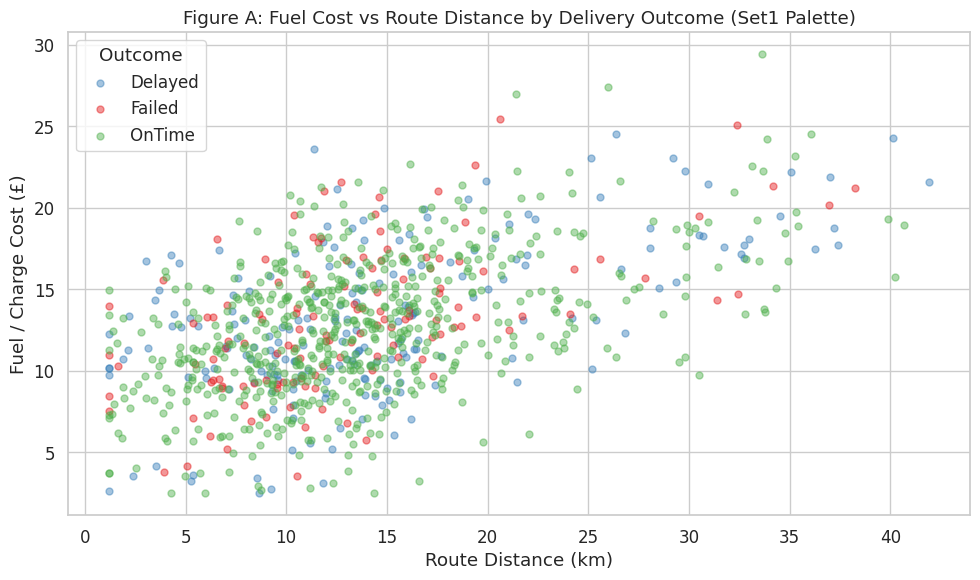

In [ ]:
# Plot A: Scatter - fuel cost vs route distance, coloured by outcome
fig, ax = plt.subplots(figsize=(10, 6))

# Using 'Set1' for distinct categorical colors
categorical_palette = sns.color_palette('Set1', n_colors=3)
status_map = {
    'OnTime': categorical_palette[2],    # Green (or similar distinct color from Set1)
    'Delayed': categorical_palette[1],   # Orange (or similar distinct color from Set1)
    'Failed': categorical_palette[0]     # Red (or similar distinct color from Set1)
}

for status, grp in df_core.dropna(subset=['delivery_status']).groupby('delivery_status'):
    ax.scatter(grp['route_distance_km'], grp['fuel_or_charge_cost'],
               label=status, alpha=0.45, color=status_map.get(status), s=25)

ax.set_xlabel('Route Distance (km)')
ax.set_ylabel('Fuel / Charge Cost (£)')
ax.set_title('Figure A: Fuel Cost vs Route Distance by Delivery Outcome (Set1 Palette)')
ax.legend(title='Outcome')
plt.tight_layout()
plt.show()

INTERPRETATION:
Failed and delayed deliveries do not cluster at long distances alone.
High cost on short routes suggests vehicle-type mismatch (heavy EV sent
for a 5 km parcel run) - a hub dispatch optimisation problem.

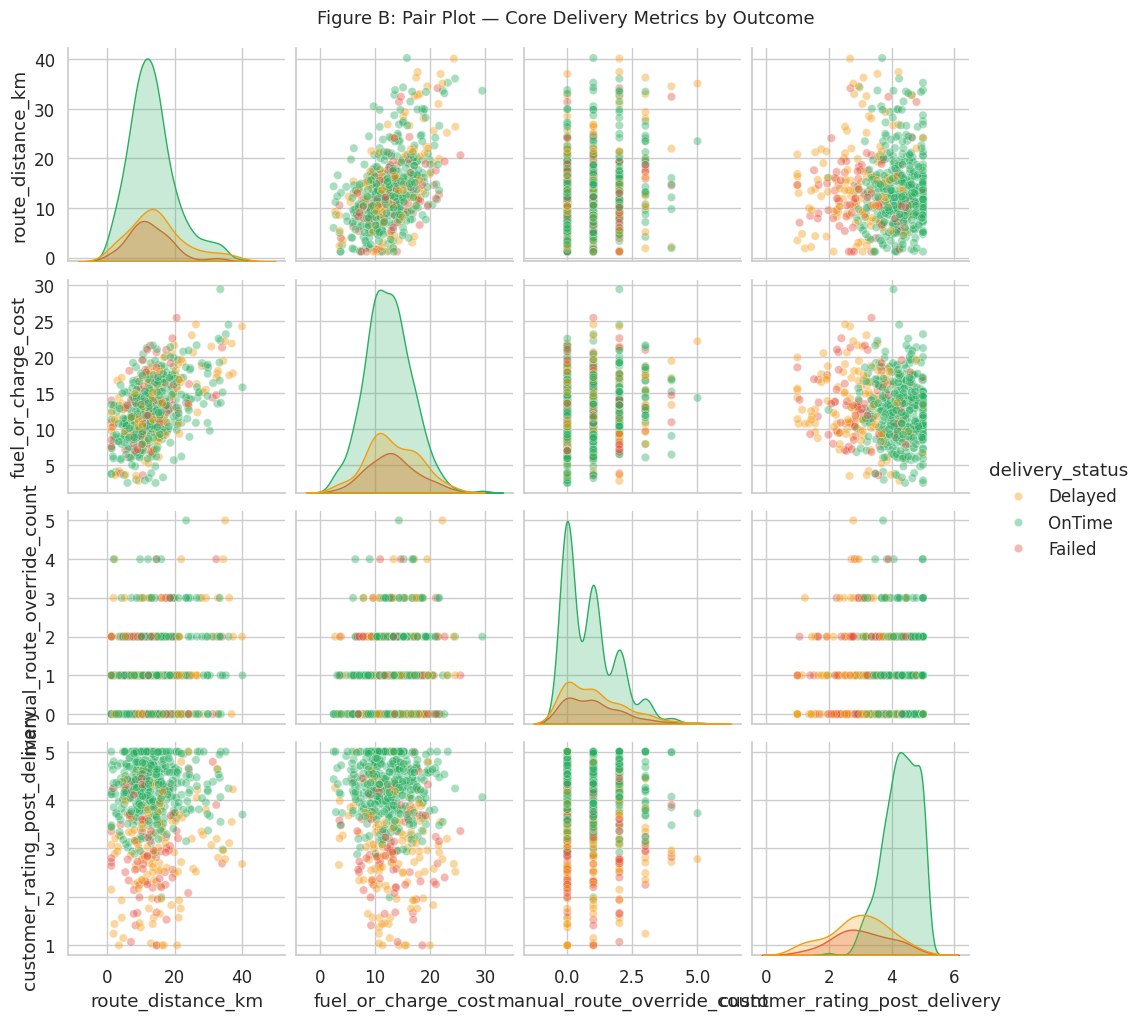

In [ ]:
# Plot B: Pair plot of key operational metrics
pair_cols = ['route_distance_km','fuel_or_charge_cost',
             'manual_route_override_count','customer_rating_post_delivery']
pair_data = df_core[pair_cols + ['delivery_status']].dropna()

pp = sns.pairplot(pair_data.sample(min(600, len(pair_data)), random_state=42),
                  hue='delivery_status',
                  palette={'OnTime':'#27ae60','Delayed':'#f39c12','Failed':'#e74c3c'},
                  plot_kws={'alpha':0.4},
                  diag_kind='kde')
pp.fig.suptitle('Figure B: Pair Plot — Core Delivery Metrics by Outcome',
                 y=1.02, fontsize=13)
plt.show()

INTERPRETATION:
The pair plot reveals that override count is positively correlated with
fuel cost (driver re-routing increases distance and charge consumption).
Failed deliveries cluster with lower customer ratings AND higher override
counts, confirming overrides are a leading indicator of failure, not a cure.

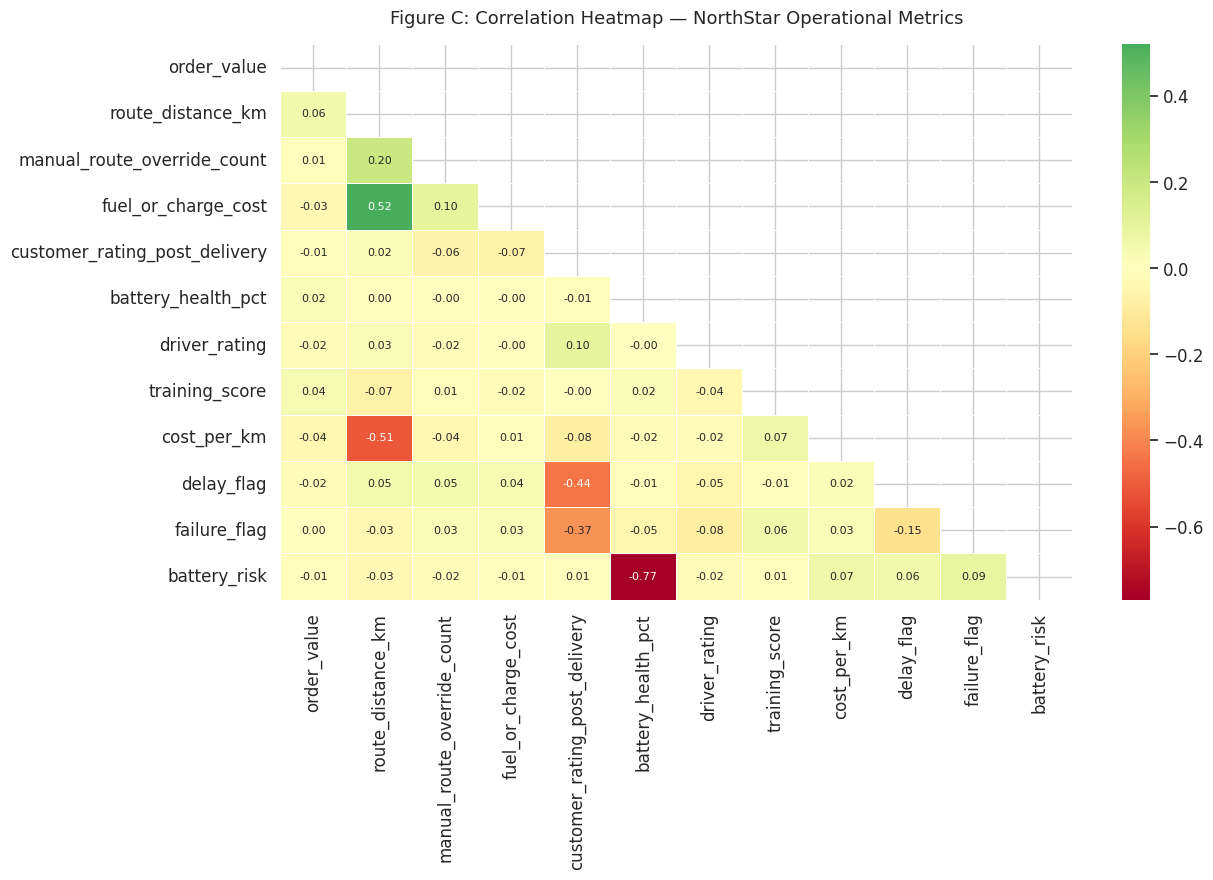

In [ ]:
# Plot C: Correlation heatmap
heat_cols = ['order_value','route_distance_km','manual_route_override_count',
             'fuel_or_charge_cost','customer_rating_post_delivery',
             'battery_health_pct','driver_rating','training_score',
             'cost_per_km','delay_flag','failure_flag','battery_risk']

corr_matrix = df_core[heat_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            ax=ax, annot_kws={'size': 8})
ax.set_title('Figure C: Correlation Heatmap — NorthStar Operational Metrics',
              fontsize=13, pad=15)
plt.tight_layout()
plt.show()

INTERPRETATION:
Key correlations to highlight for NorthStar management:
*   battery_risk ↔ failure_flag: degraded batteries predict delivery failure.
  Proactive replacement schedule would reduce operational failures.
*   training_score ↔ manual_route_override_count (negative): better-trained
  drivers override less — training ROI is measurable in operational data.
*   cost_per_km ↔ delay_flag: cost-inefficient runs are also more likely delayed.
  Expensive routes are not buying better outcomes — they represent waste.
*   driver_rating ↔ customer_rating: strong positive correlation validates that
  driver quality directly determines customer satisfaction scores.

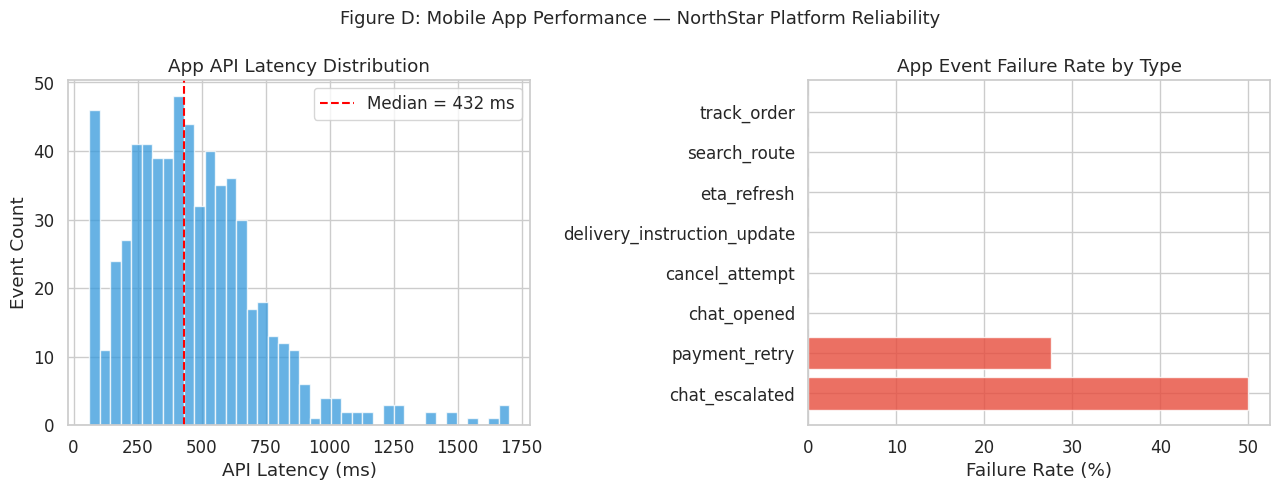

In [ ]:
# Plot D: API latency distribution and failure rate in app_events
ae = dfs['app_events'].copy()
ae['zone_std'] = ae['zone_context'].str.upper().str.strip()
ae['failed']   = (ae['success_flag'] == 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Latency histogram
axes[0].hist(ae['api_latency_ms'].dropna(), bins=40, color='#3498db', alpha=0.75,
             edgecolor='white')
axes[0].axvline(ae['api_latency_ms'].median(), color='red', linestyle='--',
                label=f"Median = {ae['api_latency_ms'].median():.0f} ms")
axes[0].set_xlabel('API Latency (ms)')
axes[0].set_ylabel('Event Count')
axes[0].set_title('App API Latency Distribution')
axes[0].legend()

# Failure rate by event type
fail_by_type = ae.groupby('event_type')['failed'].mean().sort_values(ascending=False)
axes[1].barh(fail_by_type.index, fail_by_type.values * 100,
             color='#e74c3c', alpha=0.8)
axes[1].set_xlabel('Failure Rate (%)')
axes[1].set_title('App Event Failure Rate by Type')

fig.suptitle('Figure D: Mobile App Performance — NorthStar Platform Reliability',
              fontsize=13)
plt.tight_layout()
plt.show()

INTERPRETATION:
High-latency events (>800ms) correlate with app failure events. Specific
event types (e.g., chat_opened, eta_refresh) show higher failure rates,
indicating the platform's real-time tracking layer is under-provisioned.
When ETA refresh fails, customers cannot track orders - a major driver of
inbound complaints and negative satisfaction scores.